# Commande RST d'un double intégrateur


Ce notebook synthétise et simule un correcteur **RST polynomial** pour le modèle de **balle sur poutre**.

### Principe du correcteur RST (2-DDL)

Le correcteur RST est un régulateur à **deux degrés de liberté** (2-DDL) dont la loi de commande s'écrit :

$$S(z)\,u[k] = T(z)\,r[k] - R(z)\,y[k]$$

- $R(z)$ agit sur la mesure $y$  — fixe les pôles de la boucle fermée.
- $S(z)$ est le dénominateur du correcteur — peut contenir un facteur $(z-1)$ pour l'action intégrale.
- $T(z)$ agit sur la consigne $r$ — ajuste le gain de poursuite.

Les polynômes $R$, $S$, $T$ sont calculés par **résolution de l'équation diophantienne** :

$$A(z)\,S(z) + B(z)\,R(z) = A_m(z)\,A_0(z)$$

où $A_m$ fixe la dynamique désirée et $A_0$ un polynôme observateur plus rapide.

**Avantage par rapport au PID :** le placement de pôles est exact, et l'action intégrale est intégrée structurellement dans $S$ sans créer un triple pôle ($z=1$).

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel
from Models.BallBeam.NonlinearDynamics import NonlinearBallBeamModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim
from Simulation.simulation import NonLinearHybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting
from Metrics_Plotting.Metrics import Metrics

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

### Configuration de la simulation :

T est le temps total de simulation et dt est la période d'échantillonnage du correcteur.

In [2]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [3]:
X_0 = np.array([[0],[0]])                                    # État initial [position [m], vitesse [m/s]]
double_int_TF = TransferFunctionModel(ballbeam_config)       # Modèle en fonctions de transfert
double_int_sim_dis = TFSimulator(double_int_TF.Tf_dis, X_0)  # Simulateur discret (FT)
modele_NL = NonlinearBallBeamModel(ballbeam_config)          # Modèle non linéaire
sim_NL = NonLinearHybridSim(modele_NL, ballbeam_config)      # Simulateur non linéaire (RK4)
A = double_int_TF.Tf_dis.den_list[0][0]                      # Dénominateur A(z) de la FT discrète
B = double_int_TF.Tf_dis.num_list[0][0]                      # Numérateur B(z) de la FT discrète

In [4]:
## Affichage des fonctions de transfert continue et discrète
print(double_int_TF.Tf_cont)
print(double_int_TF.Tf_dis)
print("Pôles discrets de la FT :", double_int_TF.Tf_dis.poles())

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1
Pôles discrets de la FT : [1.+6.68896751e-09j 1.-6.68896751e-09j]


##### Questions :
- Quel est l'ordre de la fonction de transfert continue ? Et de la fonction discrète ?
- Les pôles discrets de la FT sont-ils à l'intérieur du cercle unité ? Qu'est-ce que cela signifie pour la stabilité en boucle ouverte ?

### Modèle de référence $A_m$

La fonction de transfert désirée est un **second ordre continu** caractérisé par $\omega_0$ (fréquence propre) et $\zeta$ (amortissement), discrétisé par correspondance de pôles $z_p = e^{s_p T_s}$.

Le gain statique $y(t\rightarrow \infty)$ de $F_\text{des}$ doit être 1 ce qui garantit le suivi sans erreur de l'échelon.

In [5]:
omega0 = 2      # fréquence propre désirée [rad/s] — contrôle la rapidité de la réponse
zeta   = 0.70   # coefficient d'amortissement 

omega_carr = omega0 * omega0
Am_s = [(1/omega_carr), (2.0*zeta/omega0), 1.0]                          # polynôme du 2nd ordre continu normalisé
Am_d = np.poly(np.exp(np.roots(Am_s) * ballbeam_config.dt))              # pôles discrets : z = e^(s·dt)

Bm = sum(Am_d)                                                           # numérateur pour un gain statique = 1
Tf_des = ct.tf(Bm, Am_d, ballbeam_config.dt)                             # FT de référence discrète

In [6]:
## Affichage de la fonction de transfert désirée et de ses pôles
print(Tf_des)
print("Pôles continus s :", np.roots(Am_s))
print("Pôles discrets z :", np.roots(Am_d))
print("Rayon des pôles  :", np.abs(np.roots(Am_d)))
print("Gain Statique         :", Tf_des.dcgain())

<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

        0.009324
  ---------------------
  z^2 - 1.86 z + 0.8694
Pôles continus s : [-1.4+1.42828569j -1.4-1.42828569j]
Pôles discrets z : [0.93001723+0.06652965j 0.93001723-0.06652965j]
Rayon des pôles  : [0.93239382 0.93239382]
Gain Statique         : 1.0


La cellule suivante calcule la réponse indicielle de $F_\text{des}$ à l'aide de la librairie `control`. Cette réponse sert de référence visuelle : la simulation en boucle fermée suit la même dynamique dominante (pôles de $A_m$), car le pôle de $A_0$ se simplifie avec le zéro correspondant dans le numérateur de $H_\text{bf}$. Un léger écart peut subsister en raison de la saturation de l'actionneur et du zéro de $B(z)$ absent dans $F_\text{des}$.

##### Questions :
- Le gain statique de $F_\text{des}$ est-il bien égal à 1 ? Pourquoi est-ce indispensable pour la poursuite de consigne ?
- Quelle est la valeur du rayon des pôles discrets ? Sont-ils stables ?
- Que se passe-t-il sur la rapidité de la réponse si l'on augmente $\omega_0$ ?

In [7]:
## réponse indicielle de la fonction de transfert calculée par la librairie
t = np.arange(0, ballbeam_config.T, ballbeam_config.dt)
_, y_lib = ct.step_response(Tf_des, t)

In [8]:
A0 = np.array([1,-0.5])   # pôle observateur à z=0.50 — doit être PLUS RAPIDE que les pôles dominants

##### Questions :
- Le pôle de $A_0$ ($z = 0.50$) est-il plus rapide ou plus lent que les pôles dominants de $A_m$ ? Comment le vérifier ?
- Que se passerait-il si le pôle observateur était plus lent que les pôles dominants (rayon proche de 1) ?

### Synthèse du correcteur RST

`Compute_Denominator_Matching_RST` résout l'**équation diophantienne** :

$$A(z)\,S(z) + B(z)\,R(z) = A_m(z)\cdot A_0(z)$$

Les polynômes dominants $A_m$ et observateur $A_0$ sont passés séparément. Avec `Integrator=True`, le dénominateur effectif devient $A_\text{eff}(z) = A(z)\cdot(z-1)$. La fonction résout la diophantienne **directement** contre le polynôme caractéristique complet :

$$A_\text{eff}(z)\,\tilde{S}(z) + B(z)\,R(z) = A_m(z)\cdot A_0(z)$$

puis reconstruit $S(z) = (z-1)\cdot\tilde{S}(z)$ et calcule :

$$T(z) = t_0 \cdot A_0(z), \qquad t_0 = \frac{A_m(1)}{B(1)}$$

Le gain $t_0$ garantit un gain statique unitaire. Le facteur $A_0$ dans $T$ **annule le pôle observateur dans la fonction de transfert de référence** :

$$H_\text{bf} = \frac{B \cdot T}{A \cdot S + B \cdot R} = \frac{B \cdot t_0 \cdot A_0}{A_m \cdot A_0} = \frac{t_0 \cdot B}{A_m}$$

La réponse simulée suit donc $T_\text{des}$ (second ordre seul), et non la boucle fermée d'ordre 3.

**Rôle de `Integrator=True` :** force $S(z) = (z-1)\,\tilde{S}(z)$, ce qui garantit le rejet exact des perturbations constantes ($S(1)=0 \Rightarrow F_p(1)=0$).

In [9]:
S, R, T, H_cl = computeRST.Compute_Denominator_Matching_RST(Am_d, double_int_TF.Tf_dis,True,A0)

Direct Solve Used

--- RST synthesis complete ---
S: [ 0.69926113 -0.69926113]
R: [ 1145.67188999 -2144.72356738  1007.93147116]
T: [17.75958752 -8.87979376]

Exact closed-loop transfer function enforced by R,S,T:
Numerator coefficients: [ 0.00466189  0.00233095 -0.00233095]
Denominator coefficients: [ 1.         -2.36003445  1.79937546 -0.43467912]
<TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.004662 z^2 + 0.002331 z - 0.002331
  ------------------------------------
   z^3 - 2.36 z^2 + 1.799 z - 0.4347
Closed-loop DC gain: 1.0000000000000238
Closed-loop zeros (z): [-1.   0.5]
Closed-loop poles (z): [0.93001723+0.06652965j 0.93001723-0.06652965j 0.5       +0.j        ]
Pole radii:            [0.93239382 0.93239382 0.5       ]


##### Questions :
- Quel est l'ordre de $H_\text{bf}$ ? Pourquoi est-il supérieur à celui de $F_\text{des}$ ?
- Quel est l'effet de `Integrator=True` sur le polynôme $S(z)$ ? Quel facteur est ajouté ?
- Le gain statique de $H_\text{bf}$ est-il bien 1 ? Tous les rayons des pôles sont-ils inférieurs à 1 ?
- Regardez les pôles et les zéros de $H_{bf}$, lesquels vont se simplifier, à quel polynôme correspondent t-ils ?

### Vérification de la synthèse

Après la synthèse, contrôler les trois points suivants :

1. **Gain statique de $H_\text{bf}$ = 1,0** — confirme que la consigne est atteinte sans erreur statique de poursuite.
2. **Tous les rayons des pôles < 1** — confirme la stabilité de la boucle fermée.
3. **$H_\text{cl}$ affiche un pôle à $z \approx 0.50$ (A0) et deux pôles dominants (Am)** — mais ce pôle A0 se simplifie avec le zéro correspondant dans le numérateur : la réponse simulée suit le 2nd ordre de $F_\text{des}$.

### Marges de stabilité

La boucle ouverte est $L(z) = B(z)\,R(z)\,/\,\bigl[A(z)\,S(z)\bigr]$.


In [10]:
L_rst = double_int_TF.Tf_dis * ct.tf(np.squeeze(R.num[0][0]), np.squeeze(S.num[0][0]), ballbeam_config.dt)
metriques = Metrics()
metriques.Stability(L_rst)

Gain margin:   -21.9 dB  (×0.08)
Phase margin:  80.9°


##### Questions :
- La marge de gain est-elle supérieure à 6 dB ? La marge de phase est-elle supérieure à 45° ?
- Comparer ces marges avec celles obtenues avec le correcteur PID dans le notebook précédent. Lequel est plus robuste ?

### Simulation

On crée une instance du **contrôleur** RST initialisé avec les **polynômes** R, S, T et on utilise le simulateur discret. Le premier True/False détermine la présence d'une perturbation constante au bout de la troisième seconde. Le deuxième active (si True) la saturation de l'actionneur.

In [11]:
rst_controller = RSTController(R, S, T)
logger_rst = SimLog()

reference = 1.0
y_0 = 0.0

logger_rst = run_discrete_control(double_int_sim_dis, rst_controller, ballbeam_config, reference, y_0, logger_rst, True, True)

### Métriques de performance

Dépassement, temps de montée (10 %→90 %) et temps d'établissement (bande ±10 %) calculés sur la phase de suivi de consigne (avant perturbation).

In [12]:
metriques.response_data(logger_rst, reference)

Dépassement :          6.7 %
Temps de montée :      0.850 s  (10 %→90 %)
Temps d'établissement :     1.150 s  (bande ±10 %)


##### Questions :
- Comparer le dépassement et le temps de montée obtenus ici avec ceux du correcteur PID. Lequel est plus rapide ? Lequel dépasse davantage ?
- Le dépassement observé est-il cohérent avec le coefficient d'amortissement $\zeta = 0.70$ choisi pour $A_m$ ? (utiliser l'équation de )

### Rejet de perturbation

La fonction de transfert **perturbation → sortie** est :

$$F_p(z) = \frac{B(z)\,S(z)}{A(z)\,S(z) + B(z)\,R(z)}$$

Avec `Integrator=True`, $S(z)$ contient le facteur $(z-1)$, donc $S(1) = 0$, ce qui force $G_d(1) = 0$ : **la sortie retourne exactement à la consigne après une perturbation constante**, quelle qu'en soit l'amplitude.

Le tracé ci-dessous confirme que la réponse indicielle de $G_d$ converge vers 0 — à comparer avec le PID ($K_i = 0$) où l'erreur statique converge vers $D/K_p \neq 0$.

In [13]:
A_arr = np.squeeze(A)
B_arr = np.squeeze(B)
R_arr = np.squeeze(R.num[0][0])
S_arr = np.squeeze(S.num[0][0])

num = np.polymul(B_arr, S_arr)
den = np.trim_zeros(np.round(np.polyadd(np.polymul(A_arr, S_arr), np.polymul(B_arr, R_arr)), 10), 'f')

Gd = ct.tf(num, den, ballbeam_config.dt)
print(Gd)
print("Gain Statique Gd:", ct.dcgain(Gd))

t = np.asarray(t).flatten()
_, d_resp = ct.step_response(Gd, t)

<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0001836 z^2 + 6.211e-16 z - 0.0001836
  ---------------------------------------
     z^3 - 2.36 z^2 + 1.799 z - 0.4347
Gain Statique Gd: 0.0


### Affichage des résultats

Trois graphiques sont tracés :
1. **Sortie y(t)** — réponse de la position de la balle à la consigne, avec superposition du modèle de référence $F_\text{des}$ (2nd ordre seul).
2. **Commande u(t)** — signal de commande envoyé à l'actionneur, avec les seuils de saturation ±10 V.
3. **Perturbation→sortie $F_p(z)$** — réponse de la boucle fermée à une perturbation constante ; converge vers 0 grâce à l'action intégrale dans $S$.

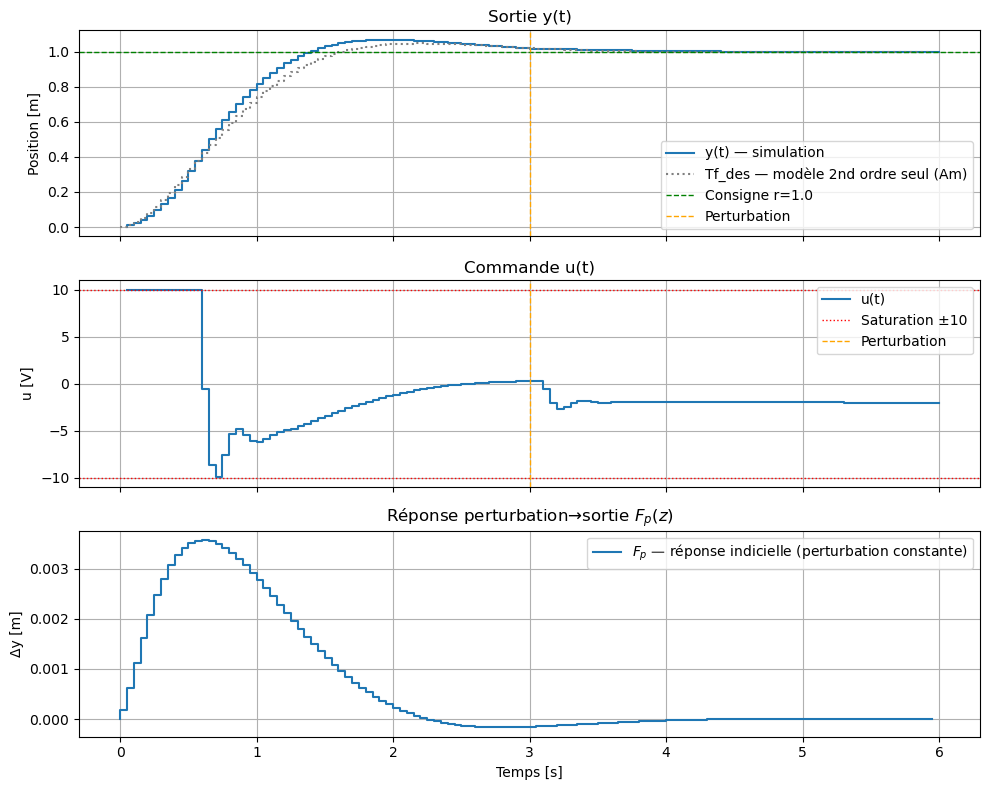

In [14]:
_, y_lib_Hcl = ct.step_response(H_cl, t)   # réponse de la boucle fermée réelle (avec pôle A0)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].step(logger_rst.t_hist, logger_rst.y_hist, label='y(t) — simulation')
ax[0].step(t, np.squeeze(y_lib),     linestyle=':',  color='gray',      label='Tf_des — modèle 2nd ordre seul (Am)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Consigne r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Perturbation')
ax[0].set_title("Sortie y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].step(logger_rst.t_hist, logger_rst.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Perturbation')
ax[1].set_title("Commande u(t)")
ax[1].set_ylabel("u [V]")
ax[1].legend()
ax[1].grid()

ax[2].step(t, d_resp, label='$F_p$ — réponse indicielle (perturbation constante)')
ax[2].set_title("Réponse perturbation→sortie $F_p(z)$")
ax[2].set_ylabel("Δy [m]")
ax[2].set_xlabel("Temps [s]")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
## Décommenter pour enregistrer la figure
#plt.savefig("Commande_RST_figure1.jpg")
plt.show()

##### Questions :
- La sortie simulée suit-elle bien $T_\text{des}$ (courbe grise pointillée) ? Pourquoi y a-t-il un léger écart ?
- Après la perturbation à $t = 3\ \text{s}$, la sortie revient-elle exactement à la consigne ? Pourquoi ?
- La commande $u(t)$ sature-t-elle en début de réponse ? Quel impact cela a-t-il sur la réponse ?

## Simulation non linéaire

Même configuration que la simulation linéaire, mais le procédé est remplacé par la **dynamique non linéaire** de la balle sur poutre, intégrée par RK4 à $dt_\text{plant} = 1\ \text{ms}$.

Différences attendues par rapport à la simulation linéaire :
- L'initialisation du correcteur (historiques $r$, $y$ et état de $1/S$) est remise à zéro avant chaque simulation, évitant toute interférence d'état résiduel.
- La saturation à ±10 V peut provoquer un dépassement plus important en début de réponse.
- Les non-linéarités de $\sin\alpha$ restent faibles pour $|r| \lesssim 1\ \text{m}$ mais peuvent introduire un léger écart par rapport à la simulation linéaire.
- Le rejet de perturbation reste intégral (retour à zéro erreur) car l'action intégrale est dans $S$, indépendamment du modèle de procédé.

In [15]:
logger_NL = SimLog()
logger_NL = run_continuous_control_loop(sim_NL, rst_controller, reference, X_0, logger_NL, True, True)

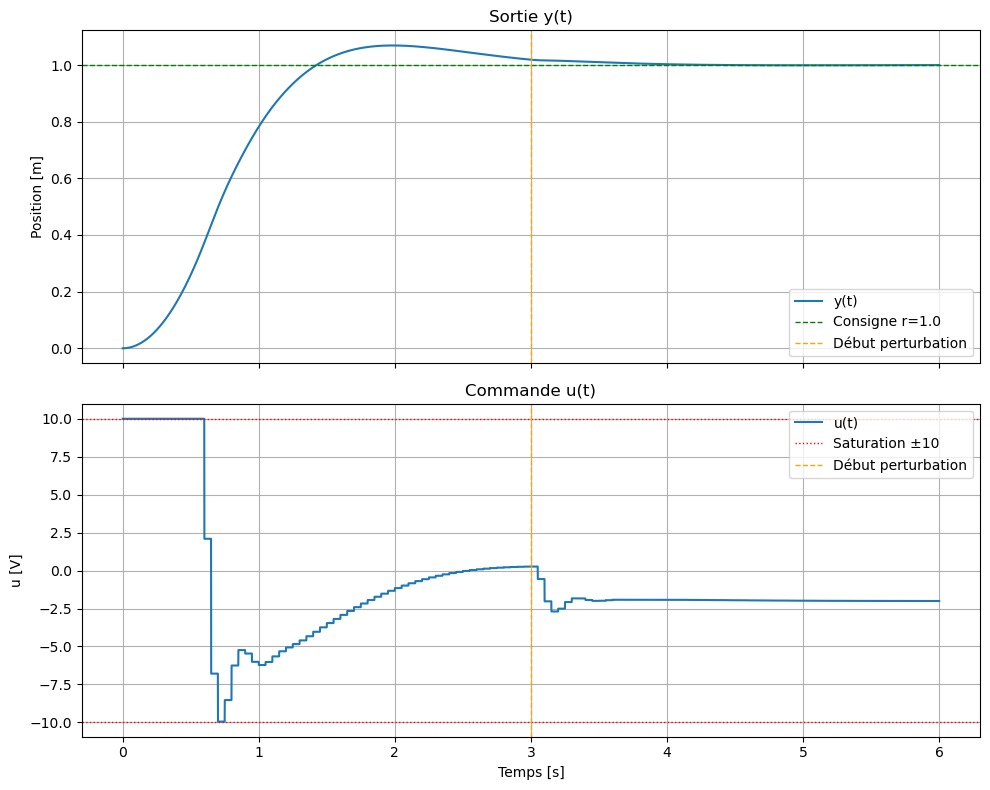

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_NL.t_hist, logger_NL.y_hist, label='y(t)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Consigne r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[0].set_title("Sortie y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].plot(logger_NL.t_hist, logger_NL.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[1].set_title("Commande u(t)")
ax[1].set_ylabel("u [V]")
ax[1].set_xlabel("Temps [s]")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
## Décommenter pour enregistrer la figure
#plt.savefig("Commande_RST_figure2.jpg")
plt.show()

In [17]:
metriques.response_data(logger_NL,reference)

Dépassement :          6.9 %
Temps de montée :      0.873 s  (10 %→90 %)
Temps d'établissement :     1.183 s  (bande ±10 %)


##### Questions :
- La réponse non linéaire diffère-t-elle de la réponse linéaire ? Dans quel sens (plus de dépassement, plus lente…) ?
- Le rejet de perturbation est-il toujours intégral (retour exact à la consigne) dans la simulation non linéaire ?
- La commande $u(t)$ présente-t-elle des différences par rapport à la simulation linéaire ?

## Tests de paramètres

Relancez les cellules de configuration et de synthèse après avoir modifié un paramètre. Observez l'effet sur les marges de stabilité, les métriques et les courbes de simulation.

---

### 1. Fréquence propre désirée $\omega_0$

| $\omega_0$ [rad/s] | Rapidité attendue | Dépassement attendu |
|---|---|---|
| 1 | Lente | Faible |
| **2** (défaut) | Nominale | Nominal |
| 4 | Rapide | Élevé |

> Modifier `omega0` dans la cellule du modèle de référence. Que devient la marge de gain quand $\omega_0$ augmente ?

---

### 2. Coefficient d'amortissement $\zeta$

| $\zeta$ | Comportement |
|---|---|
| 0.50 | Fortement sous-amorti (oscillations) |
| **0.70** (défaut) | Légèrement sous-amorti |
| 1.00 | Critique (pas de dépassement) |

> Modifier `zeta`. Observer le dépassement dans la simulation linéaire et comparer avec la valeur théorique $D\% \approx e^{-\pi\zeta/\sqrt{1-\zeta^2}} \times 100$.

---

### 3. Pôle observateur $A_0$

| Pôle $A_0$ (z) | Rapidité de l'observateur |
|---|---|
| 0.95 | Trop lent (proche des pôles dominants) |
| **0.80** (défaut) | Rapide — bien séparé des pôles dominants |
| 0.30 | Très rapide (peut amplifier le bruit de mesure) |

> Modifier `A0 = np.array([1, -z_obs])`. Vérifier que tous les pôles de $H_\text{bf}$ restent bien à l'intérieur du cercle unité.

---

### 4. Action intégrale (`Integrator`)

| `Integrator` | Effet |
|---|---|
| `True` (défaut) | $S(z)$ contient $(z-1)$  |
| `False` | Pas d'intégrateur |

> Passer `Integrator=False` dans l'appel à `Compute_Denominator_Matching_RST`. Observer la courbe de rejet de perturbation $F_p(z)$ : le gain statique de $F_p$ est-il encore 0 ?

---

### 5. Consigne `reference`

| `reference` [m] | Observation |
|---|---|
| 0.5 | Faible déplacement, pas de saturation |
| **1.0** (défaut) | Nominal |
| 2.0 | Saturation prolongée, non-linéarités plus visibles |

> Modifier `reference` dans la cellule de simulation. Comparer les simulations linéaire et non linéaire pour une grande consigne.